# My final project
# Joaquin Carlos Garcia De Joya

In [1]:
import numpy as np
import sep
import astropy.io.fits as astropyio
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Ellipse

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [2]:
data = astropyio.getdata("finaldata.fits")

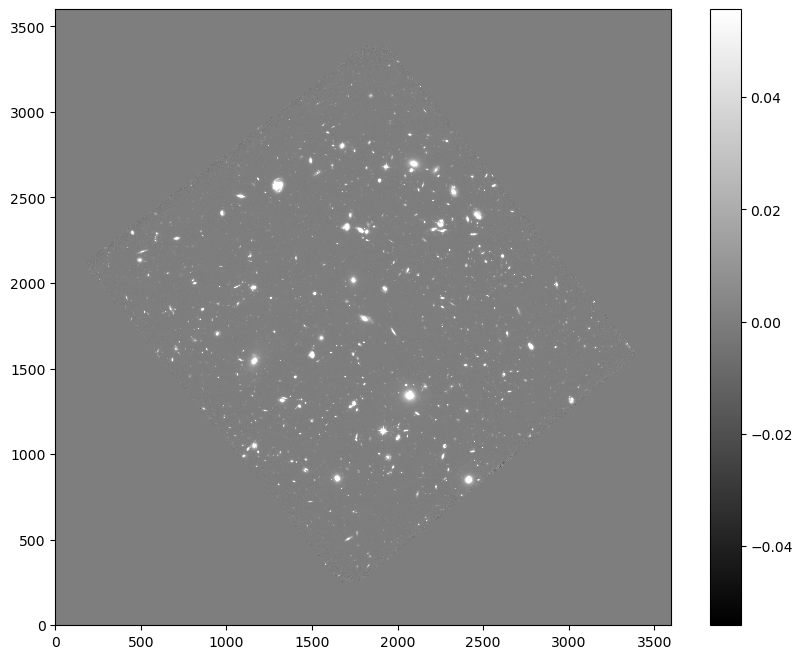

In [3]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

In [4]:
data = data.astype(data.dtype.newbyteorder('='))
bkg = sep.Background(data)

In [5]:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [6]:
bkg_image = bkg.back()

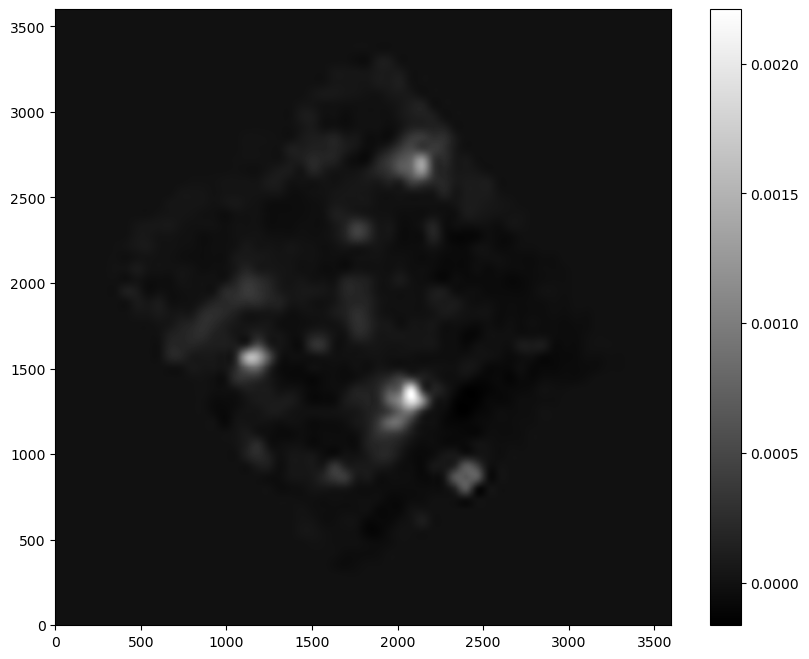

In [7]:
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [8]:
bkg_rms = bkg.rms()

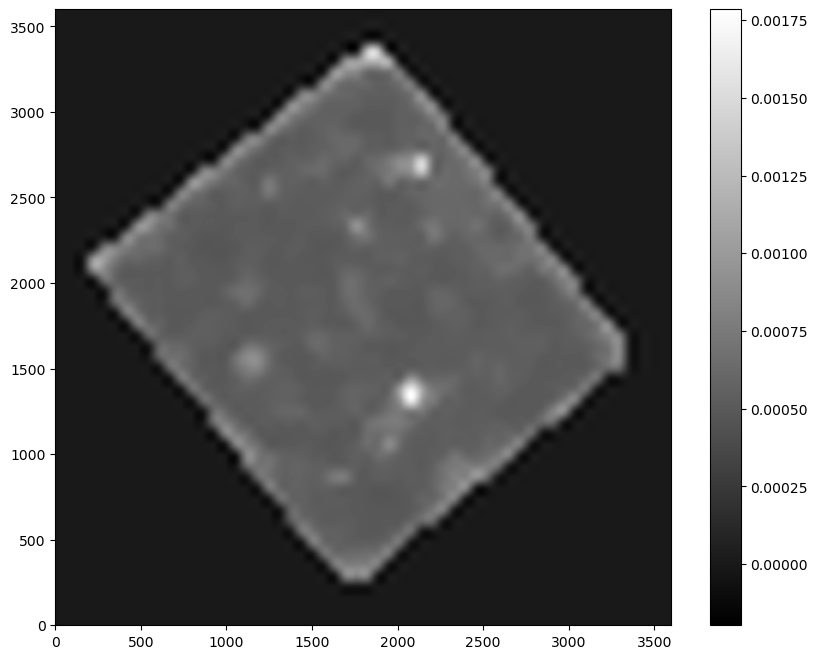

In [9]:
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [10]:
data_sub = data - bkg

In [11]:
objects = sep.extract(data_sub, 200, err=bkg.globalrms)

In [12]:
len(objects)

132

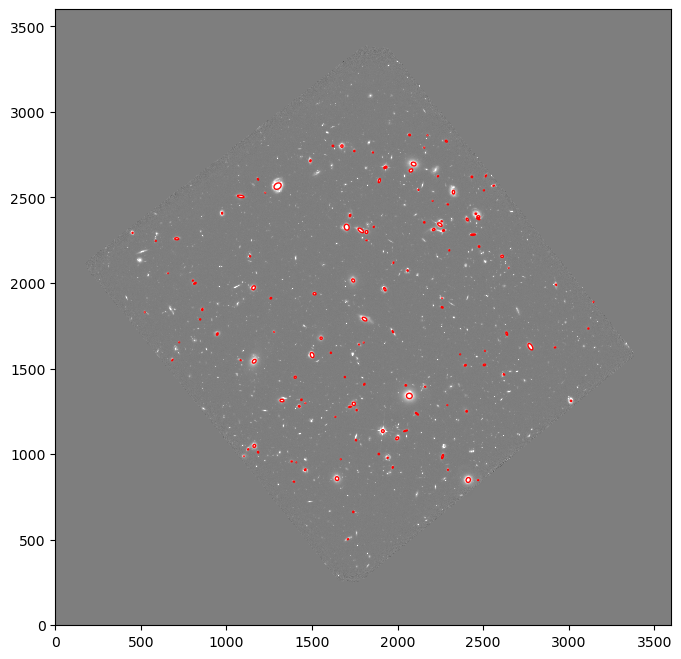

In [13]:
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [14]:
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

In [15]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [16]:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 3.223413 +/- 1.795389
object 1: flux = 8.205215 +/- 2.864476
object 2: flux = 3.358505 +/- 1.832625
object 3: flux = 3.299307 +/- 1.816402
object 4: flux = 65.665895 +/- 8.103450
object 5: flux = 72.381953 +/- 8.507759
object 6: flux = 3.015562 +/- 1.736540
object 7: flux = 3.956054 +/- 1.988985
object 8: flux = 3.754888 +/- 1.937756
object 9: flux = 2.229514 +/- 1.493159


## There were 132 sources in the data. Below is a histogram of their fluxes

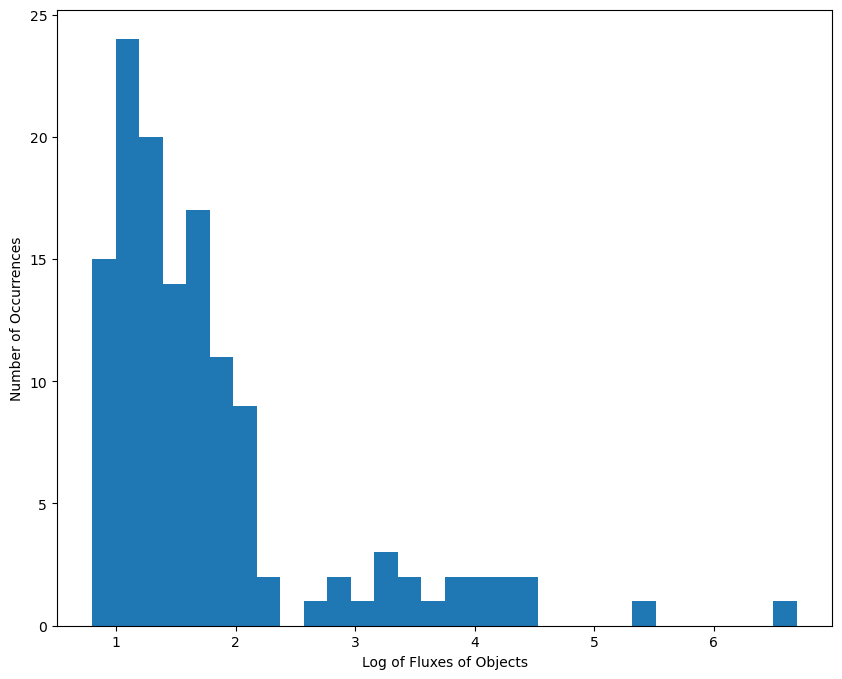

In [17]:
yes = np.concatenate((np.linspace(-0.1, 1,num=1000),))
plt.hist(np.log(flux),bins=30)
plt.xlabel('Log of Fluxes of Objects')
plt.ylabel('Number of Occurrences')
plt.show()

In [18]:
mean = np.mean(flux)
print("Our mean is", mean)
std = np.std(flux)
print("Our standard deviation is", std)
median = np.median(flux)
print("Our median is", median)

Our mean is 17.20869904232631
Our standard deviation is 72.84418161680753
Our median is 4.370875821113588


## The mean of the fluxes is around 17.2087
## The standard deviation of the fluxes is around 72.8442
## The median of the fluxes is around 4.3709

In [19]:
M_outlier = max(objects['flux'])
print(f"The largest outlier in the distribution is {M_outlier:0.3f}.")

The largest outlier in the distribution is 1140.127.


In [20]:
M_sigma_amount = max(objects['flux'])/std
print(f"The largest outlier is {M_sigma_amount:0.3f} standard deviations from the mean.")

The largest outlier is 15.652 standard deviations from the mean.


## The largest outlier in the distribution is around 1140.127.

## The largest outlier is around 15.652 standard deviations from the mean.